# Notebook 08: Comparative Evaluation

**Dissertation: "Agentic AI for Sovereign Risk Assessment under Climate-Related Fiscal Stress"**

This notebook loads all trained agents and calibrated benchmarks, runs a standardised evaluation protocol on all 9 profiles (200 episodes each), and produces the results tables and figures for **Chapter 4**.

| Aspect | Detail |
|---|---|
| Strategies | Random, Bohn (1998), EU SGP, Passive Stress Test, DQN, PPO |
| Profiles | 9 (3 economy types × 3 climate risk tiers) |
| Episodes per cell | 200 (N_EVAL_EPISODES) |
| Evaluation seed | 99 (held-out; training used seed 42) |
| Training | None — models loaded from `outputs/models/` |

**Chapter 4 outputs:** Tables 4.1 (evaluation results), Figures R1–R7, cross-algorithmic consistency metrics, stress-test comparison.

In [1]:
# ── Imports and path setup ─────────────────────────────────────────────────
import sys, os, json, pickle, warnings

# Always run from project root so relative data paths work
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
import torch

from src.environment.sovereign_risk_env import SovereignRiskEnv
from src.environment.config import load_profile, list_profiles
from src.benchmarks.bohn_fiscal_reaction import FiscalPolicy, RandomPolicy
from src.benchmarks.calibrated_bohn import CalibratedBohn
from src.benchmarks.fixed_deficit_target import FixedDeficitTarget
from src.benchmarks.passive_stress_test import PassiveStressTest
from src.agents.dqn.agent import DQNAgent
from stable_baselines3 import PPO

print('All imports OK')
print(f'Working directory: {os.getcwd()}')

All imports OK
Working directory: C:\Users\nduka\OneDrive\Desktop\Claude\sovereign-risk-agent


In [2]:
# ── Constants and configuration ────────────────────────────────────────────
CONFIG_PATH  = 'data/processed/transition_parameters.json'
SCALING_PATH = 'data/processed/scaling_parameters.json'
MODELS_DIR   = 'outputs/models'
RESULTS_DIR  = 'outputs/results'
FIGURES_DIR  = 'outputs/figures'
BENCH_CONFIG = 'outputs/benchmarks/benchmark_config.json'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

EVAL_SEED       = 99    # held-out seed; training used seed 42
N_EVAL_EPISODES = 200

PROFILES = list_profiles(CONFIG_PATH)
print(f'Profiles ({len(PROFILES)}):', PROFILES)

STRATEGY_NAMES = ['Random', 'Bohn', 'SGP', 'Passive', 'DQN', 'PPO']

# Okabe-Ito colorblind-friendly palette (6 strategies)
STRATEGY_COLORS = {
    'Random':  '#999999',   # grey
    'Bohn':    '#0072B2',   # blue
    'SGP':     '#E69F00',   # orange
    'Passive': '#D55E00',   # vermilion
    'DQN':     '#009E73',   # bluish green
    'PPO':     '#CC79A7',   # reddish purple
}

ACTION_NAMES = {
    0: 'Severe austerity',
    1: 'Moderate austerity',
    2: 'Maintain',
    3: 'Moderate stimulus',
    4: 'Large stimulus',
    5: 'Climate adaptation',
}

REWARD_COMPONENTS = [
    'debt_penalty', 'interest_penalty', 'adjustment_penalty',
    'output_penalty', 'climate_penalty', 'reduction_reward', 'growth_reward'
]

# Colours for stacked reward decomposition (tab10)
COMPONENT_COLORS = {
    'debt_penalty':       '#d62728',
    'interest_penalty':   '#ff7f0e',
    'adjustment_penalty': '#bcbd22',
    'output_penalty':     '#8c564b',
    'climate_penalty':    '#9467bd',
    'reduction_reward':   '#2ca02c',
    'growth_reward':      '#1f77b4',
}

print(f'EVAL_SEED={EVAL_SEED}, N_EVAL_EPISODES={N_EVAL_EPISODES}')

Profiles (9): ['Advanced_Low', 'Advanced_Medium', 'Advanced_High', 'Emerging_Market_Low', 'Emerging_Market_Medium', 'Emerging_Market_High', 'Developing_Low', 'Developing_Medium', 'Developing_High']
EVAL_SEED=99, N_EVAL_EPISODES=200


## Setup: Load Models and Benchmark Configurations

In [3]:
# ── Load DQN agents ────────────────────────────────────────────────────────
dqn_agents = {}
for profile in PROFILES:
    path = f'{MODELS_DIR}/dqn_{profile}/model.pt'
    if not os.path.exists(path):
        print(f'WARNING: DQN model missing for {profile}')
        continue
    agent = DQNAgent(state_dim=7, action_dim=6)
    agent.load(path)
    dqn_agents[profile] = agent
print(f'Loaded {len(dqn_agents)}/9 DQN agents')

Loaded 9/9 DQN agents


In [4]:
# ── Load PPO agents ────────────────────────────────────────────────────────
ppo_agents = {}
for profile in PROFILES:
    path = f'{MODELS_DIR}/ppo_{profile}/final_model'
    if not os.path.exists(path + '.zip'):
        print(f'WARNING: PPO model missing for {profile}')
        continue
    model = PPO.load(path)
    ppo_agents[profile] = model
print(f'Loaded {len(ppo_agents)}/9 PPO agents')

Loaded 9/9 PPO agents


In [5]:
# ── Load benchmark config and create calibrated Bohn instances ─────────────
with open(BENCH_CONFIG) as f:
    bench_cfg = json.load(f)

calibrated_bohn = {}
for profile in PROFILES:
    calibrated_bohn[profile] = CalibratedBohn.for_profile(
        profile, CONFIG_PATH, SCALING_PATH
    )

print('Calibrated Bohn instances:')
for p, b in calibrated_bohn.items():
    print(f'  {p}: alpha={b.alpha:.4f}, beta={b.beta:.4f}, gamma={b.gamma:.4f}, g_base={b._growth_base:.2f}')

print()
print('SGP config:', json.dumps(bench_cfg.get('sgp', {}), indent=2))
print('Passive: always action 2 (Maintain current policy)')

Profile 'Advanced_High' is sparse (2 countries). The following null parameters have been substituted with Advanced_Low fallback values: {'initial_primary_balance': -0.106, 'initial_interest_rate': 5.8217, 'initial_risk_premium': 4.8411, 'rate_base': 5.8217}


Profile 'Emerging_Market_Low': calibrated climate_fiscal_cost is +0.547 (wrong sign — implies disasters improve fiscal balance). Overriding to -0.5 for all Emerging Market profiles. See config.py for methodology rationale.


Profile 'Emerging_Market_Medium': calibrated climate_fiscal_cost is +0.547 (wrong sign — implies disasters improve fiscal balance). Overriding to -0.5 for all Emerging Market profiles. See config.py for methodology rationale.


Profile 'Emerging_Market_High': calibrated climate_fiscal_cost is +0.547 (wrong sign — implies disasters improve fiscal balance). Overriding to -0.5 for all Emerging Market profiles. See config.py for methodology rationale.


Calibrated Bohn instances:
  Advanced_Low: alpha=0.0142, beta=0.0040, gamma=0.4804, g_base=2.48
  Advanced_Medium: alpha=0.0142, beta=0.0040, gamma=0.4804, g_base=3.63
  Advanced_High: alpha=0.0142, beta=0.0040, gamma=0.4804, g_base=1.40
  Emerging_Market_Low: alpha=-1.8499, beta=0.0132, gamma=0.4064, g_base=3.89
  Emerging_Market_Medium: alpha=-1.8499, beta=0.0132, gamma=0.4064, g_base=3.46
  Emerging_Market_High: alpha=-1.8499, beta=0.0132, gamma=0.4064, g_base=2.37
  Developing_Low: alpha=-2.5346, beta=-0.0144, gamma=0.1828, g_base=5.51
  Developing_Medium: alpha=-2.5346, beta=-0.0144, gamma=0.1828, g_base=4.22
  Developing_High: alpha=-2.5346, beta=-0.0144, gamma=0.1828, g_base=4.46

SGP config: {
  "deficit_target": -3.0,
  "debt_target": 60.0,
  "adjustment_speed": 0.5,
  "reference": "European Commission (2020) Vade Mecum SGP, IP-129"
}
Passive: always action 2 (Maintain current policy)


In [6]:
# ── Policy wrapper classes ─────────────────────────────────────────────────

class DQNPolicy(FiscalPolicy):
    """Wraps the PyTorch DQN agent for standardised evaluation."""
    def __init__(self, agent: DQNAgent):
        self.agent = agent
    def select_action(self, observation, info):
        return self.agent.select_action(observation, evaluate=True)
    def __repr__(self):
        return 'DQN'

class PPOPolicy(FiscalPolicy):
    """Wraps the SB3 PPO model for standardised evaluation."""
    def __init__(self, model):
        self.model = model
    def select_action(self, observation, info):
        action, _ = self.model.predict(observation, deterministic=True)
        return int(action)
    def __repr__(self):
        return 'PPO'

print('DQNPolicy and PPOPolicy defined.')

DQNPolicy and PPOPolicy defined.


## Part 1: Evaluation Protocol

All 6 strategies are evaluated on the same environment instances (EVAL_SEED=99), ensuring identical shock sequences for fair comparison. Evaluation is **deterministic** (no epsilon exploration for DQN, deterministic=True for PPO).

In [7]:
def evaluate_strategy(
    policy: FiscalPolicy,
    profile: str,
    n_episodes: int = 200,
    seed: int = 99,
    climate_stress_factor: float = 1.0,
) -> dict:
    """
    Run n_episodes and collect comprehensive metrics.

    Parameters
    ----------
    climate_stress_factor : float
        Multiplier applied to climate_event_probability and
        climate_conditional_mean. 1.0 = baseline; 2.0 = NGFS Hot House 2x.
    """
    env = SovereignRiskEnv(
        profile=profile,
        config_path=CONFIG_PATH,
        scaling_path=SCALING_PATH,
        seed=seed,
    )
    if climate_stress_factor != 1.0:
        env.config.climate_event_probability *= climate_stress_factor
        env.config.climate_conditional_mean  *= climate_stress_factor

    terminal_debts     = []
    cumulative_rewards = []
    crisis_count       = 0
    action_counts      = {a: 0 for a in range(6)}
    total_steps        = 0
    all_growth         = []
    component_sums     = {}
    trajectories       = []
    raw                = {}  # fallback for terminal debt

    for ep in range(n_episodes):
        obs, info = env.reset()
        policy.reset()
        ep_reward    = 0.0
        ep_traj      = {'debt': [], 'growth': [], 'actions': [], 'climate': []}

        done = False
        while not done:
            action = policy.select_action(obs, info)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            ep_reward += reward
            action_counts[action] += 1
            total_steps += 1

            raw = info.get('raw_state', {})
            all_growth.append(raw.get('growth', 0.0))

            for k, v in info.get('reward_components', {}).items():
                component_sums[k] = component_sums.get(k, 0.0) + v

            if ep < 10:
                ep_traj['debt'].append(raw.get('debt', 0.0))
                ep_traj['growth'].append(raw.get('growth', 0.0))
                ep_traj['actions'].append(action)
                ep_traj['climate'].append(info.get('climate_damage', 0.0))

        terminal_debts.append(raw.get('debt', 0.0))
        cumulative_rewards.append(ep_reward)
        if terminated and info.get('terminated_by_crisis', False):
            crisis_count += 1
        if ep < 10:
            trajectories.append(ep_traj)

    env.close()

    reward_component_means = (
        {k: v / total_steps for k, v in component_sums.items()}
        if total_steps > 0 else {}
    )
    action_dist = (
        {a: c / total_steps * 100 for a, c in action_counts.items()}
        if total_steps > 0 else {a: 0.0 for a in range(6)}
    )

    return {
        'terminal_debts':         terminal_debts,
        'cumulative_rewards':     cumulative_rewards,
        'crisis_count':           crisis_count,
        'crisis_rate':            crisis_count / n_episodes * 100,
        'action_counts':          action_counts,
        'total_steps':            total_steps,
        'mean_growth':            float(np.mean(all_growth)) if all_growth else 0.0,
        'mean_terminal_debt':     float(np.mean(terminal_debts)),
        'median_terminal_debt':   float(np.median(terminal_debts)),
        'mean_cumulative_reward': float(np.mean(cumulative_rewards)),
        'reward_component_means': reward_component_means,
        'trajectories':           trajectories,
        'action_distribution':    action_dist,
    }

print('evaluate_strategy defined.')

evaluate_strategy defined.


In [8]:
# ── Run full evaluation: 6 strategies x 9 profiles x 200 episodes ──────────
results = {}
total_ep_count = 0

for profile in PROFILES:
    print(f'\nEvaluating: {profile}')

    strategies = {
        'Random':  RandomPolicy(),
        'Bohn':    calibrated_bohn[profile],
        'SGP':     FixedDeficitTarget(),
        'Passive': PassiveStressTest(),
    }
    if profile in dqn_agents:
        strategies['DQN'] = DQNPolicy(dqn_agents[profile])
    else:
        print(f'  [DQN missing for {profile}]')
    if profile in ppo_agents:
        strategies['PPO'] = PPOPolicy(ppo_agents[profile])
    else:
        print(f'  [PPO missing for {profile}]')

    results[profile] = {}
    for name, policy in strategies.items():
        r = evaluate_strategy(policy, profile, N_EVAL_EPISODES, EVAL_SEED)
        results[profile][name] = r
        total_ep_count += N_EVAL_EPISODES
        print(
            f'  {name:>8s}: debt={r["mean_terminal_debt"]:>7.1f}%  '
            f'reward={r["mean_cumulative_reward"]:>8.1f}  '
            f'crises={r["crisis_rate"]:>5.1f}%'
        )

print(f'\nEvaluation complete. Total episodes run: {total_ep_count:,}')


Evaluating: Advanced_Low


    Random: debt=  190.0%  reward=  -672.1  crises= 77.0%
      Bohn: debt=  156.8%  reward=  -562.0  crises= 59.5%


       SGP: debt=  161.0%  reward=  -567.2  crises= 62.5%
   Passive: debt=  170.3%  reward=  -571.9  crises= 65.0%


       DQN: debt=   42.7%  reward=  -244.4  crises= 13.5%


       PPO: debt=   15.5%  reward=  -243.3  crises=  5.5%

Evaluating: Advanced_Medium
    Random: debt=  178.5%  reward=  -680.2  crises= 68.5%


...

       PPO: debt=   32.8%  reward=  -210.5  crises= 14.5%

Evaluating: Developing_High
    Random: debt=  214.0%  reward=  -627.1  crises= 85.0%


      Bohn: debt=  206.6%  reward=  -611.9  crises= 81.0%
       SGP: debt=  197.8%  reward=  -608.8  crises= 76.0%


   Passive: debt=  197.5%  reward=  -596.3  crises= 79.0%


       DQN: debt=   74.2%  reward=  -370.5  crises= 30.5%


       PPO: debt=   95.0%  reward=  -413.7  crises= 38.0%

Evaluation complete. Total episodes run: 10,800


## Part 2: Primary Results Table

In [9]:
# ── Build results DataFrame (Table 4.1) ───────────────────────────────────
rows = []
for profile in PROFILES:
    for strategy in STRATEGY_NAMES:
        if strategy not in results.get(profile, {}):
            continue
        r = results[profile][strategy]
        row = {
            'Profile':              profile,
            'Strategy':             strategy,
            'Mean Terminal Debt':   round(r['mean_terminal_debt'], 1),
            'Median Terminal Debt': round(r['median_terminal_debt'], 1),
            'Mean Cumul. Reward':   round(r['mean_cumulative_reward'], 1),
            'Crisis Rate (%)':      round(r['crisis_rate'], 1),
            'Mean Growth (%)':      round(r['mean_growth'], 2),
        }
        for a, aname in ACTION_NAMES.items():
            short = aname.split()[0]
            row[f'Act{a}-{short}(%)'] = round(r['action_distribution'].get(a, 0.0), 1)
        rows.append(row)

results_df = pd.DataFrame(rows)
results_df.to_csv(f'{RESULTS_DIR}/evaluation_results.csv', index=False)
print(f'Saved evaluation_results.csv  ({len(results_df)} rows)')

# Display with strategy-coloured styling
display_cols = ['Profile', 'Strategy', 'Mean Terminal Debt',
                'Median Terminal Debt', 'Mean Cumul. Reward', 'Crisis Rate (%)', 'Mean Growth (%)']
print()
print(results_df[display_cols].to_string(index=False))

Saved evaluation_results.csv  (54 rows)

               Profile Strategy  Mean Terminal Debt  Median Terminal Debt  Mean Cumul. Reward  Crisis Rate (%)  Mean Growth (%)
          Advanced_Low   Random               190.0                 216.4              -672.1             77.0             2.47
          Advanced_Low     Bohn               156.8                 208.5              -562.0             59.5             2.35
          Advanced_Low      SGP               161.0                 208.9              -567.2             62.5             2.42
          Advanced_Low  Passive               170.3                 209.7              -571.9             65.0             2.33
          Advanced_Low      DQN                42.7                   1.8              -244.4             13.5             2.53
          Advanced_Low      PPO                15.5                   0.0              -243.3              5.5             2.42
       Advanced_Medium   Random               178.5            

In [10]:
# ── Key comparison metrics ─────────────────────────────────────────────────
print('=== Strategy Rankings by Mean Cumulative Reward ===')
for profile in PROFILES:
    pres = results.get(profile, {})
    profile_rewards = {
        s: pres[s]['mean_cumulative_reward']
        for s in STRATEGY_NAMES if s in pres
    }
    ranked = sorted(profile_rewards.items(), key=lambda x: x[1], reverse=True)
    rank_str = ' > '.join(f'{n}({v:.0f})' for n, v in ranked)
    print(f'  {profile:<30}: {rank_str}')

print()
print('=== DQN vs Bohn (lower debt AND higher reward = DQN wins) ===')
dqn_wins_debt, dqn_wins_reward = [], []
for profile in PROFILES:
    if 'DQN' not in results.get(profile, {}) or 'Bohn' not in results.get(profile, {}):
        continue
    dqn = results[profile]['DQN']
    bohn = results[profile]['Bohn']
    if dqn['mean_terminal_debt'] < bohn['mean_terminal_debt']:
        dqn_wins_debt.append(profile)
    if dqn['mean_cumulative_reward'] > bohn['mean_cumulative_reward']:
        dqn_wins_reward.append(profile)
print(f'  DQN lower debt than Bohn:    {dqn_wins_debt}')
print(f'  DQN higher reward than Bohn: {dqn_wins_reward}')

print()
print('=== PPO vs Bohn ===')
ppo_wins_debt, ppo_wins_reward = [], []
for profile in PROFILES:
    if 'PPO' not in results.get(profile, {}) or 'Bohn' not in results.get(profile, {}):
        continue
    ppo = results[profile]['PPO']
    bohn = results[profile]['Bohn']
    if ppo['mean_terminal_debt'] < bohn['mean_terminal_debt']:
        ppo_wins_debt.append(profile)
    if ppo['mean_cumulative_reward'] > bohn['mean_cumulative_reward']:
        ppo_wins_reward.append(profile)
print(f'  PPO lower debt than Bohn:    {ppo_wins_debt}')
print(f'  PPO higher reward than Bohn: {ppo_wins_reward}')

print()
print('=== RL improvement over Passive (mean cumulative reward) ===')
for profile in PROFILES:
    passive_r = results[profile].get('Passive', {}).get('mean_cumulative_reward', float('nan'))
    dqn_r     = results[profile].get('DQN', {}).get('mean_cumulative_reward', float('nan'))
    ppo_r     = results[profile].get('PPO', {}).get('mean_cumulative_reward', float('nan'))
    print(f'  {profile:<30}: DQN-Passive={dqn_r-passive_r:+7.1f}  PPO-Passive={ppo_r-passive_r:+7.1f}')

print()
print('=== Zero crisis rate profiles ===')
for profile in PROFILES:
    for strat in STRATEGY_NAMES:
        if strat in results.get(profile, {}):
            if results[profile][strat]['crisis_rate'] == 0.0:
                print(f'  {strat} on {profile}: 0% crisis rate')

=== Strategy Rankings by Mean Cumulative Reward ===
  Advanced_Low                  : PPO(-243) > DQN(-244) > Bohn(-562) > SGP(-567) > Passive(-572) > Random(-672)
  Advanced_Medium               : DQN(-243) > PPO(-264) > Bohn(-602) > SGP(-622) > Passive(-625) > Random(-680)
  Advanced_High                 : PPO(-121) > DQN(-137) > Passive(-377) > Bohn(-399) > Random(-433) > SGP(-533)
  Emerging_Market_Low           : DQN(-332) > PPO(-336) > Random(-677) > Bohn(-687) > Passive(-698) > SGP(-699)
  Emerging_Market_Medium        : DQN(-652) > PPO(-712) > Passive(-784) > Bohn(-821) > SGP(-841) > Random(-856)
  Emerging_Market_High          : PPO(-159) > DQN(-162) > Passive(-515) > Random(-553) > SGP(-558) > Bohn(-589)
  Developing_Low                : DQN(-406) > PPO(-431) > Passive(-720) > Random(-723) > SGP(-771) > Bohn(-800)
  Developing_Medium             : DQN(-192) > PPO(-211) > Bohn(-609) > Random(-620) > Passive(-624) > SGP(-641)
  Developing_High               : DQN(-370) > PPO(-4

## Part 3: Results Visualisation

All figures use the Okabe-Ito colorblind-friendly palette, 300 DPI, saved as PNG and SVG.

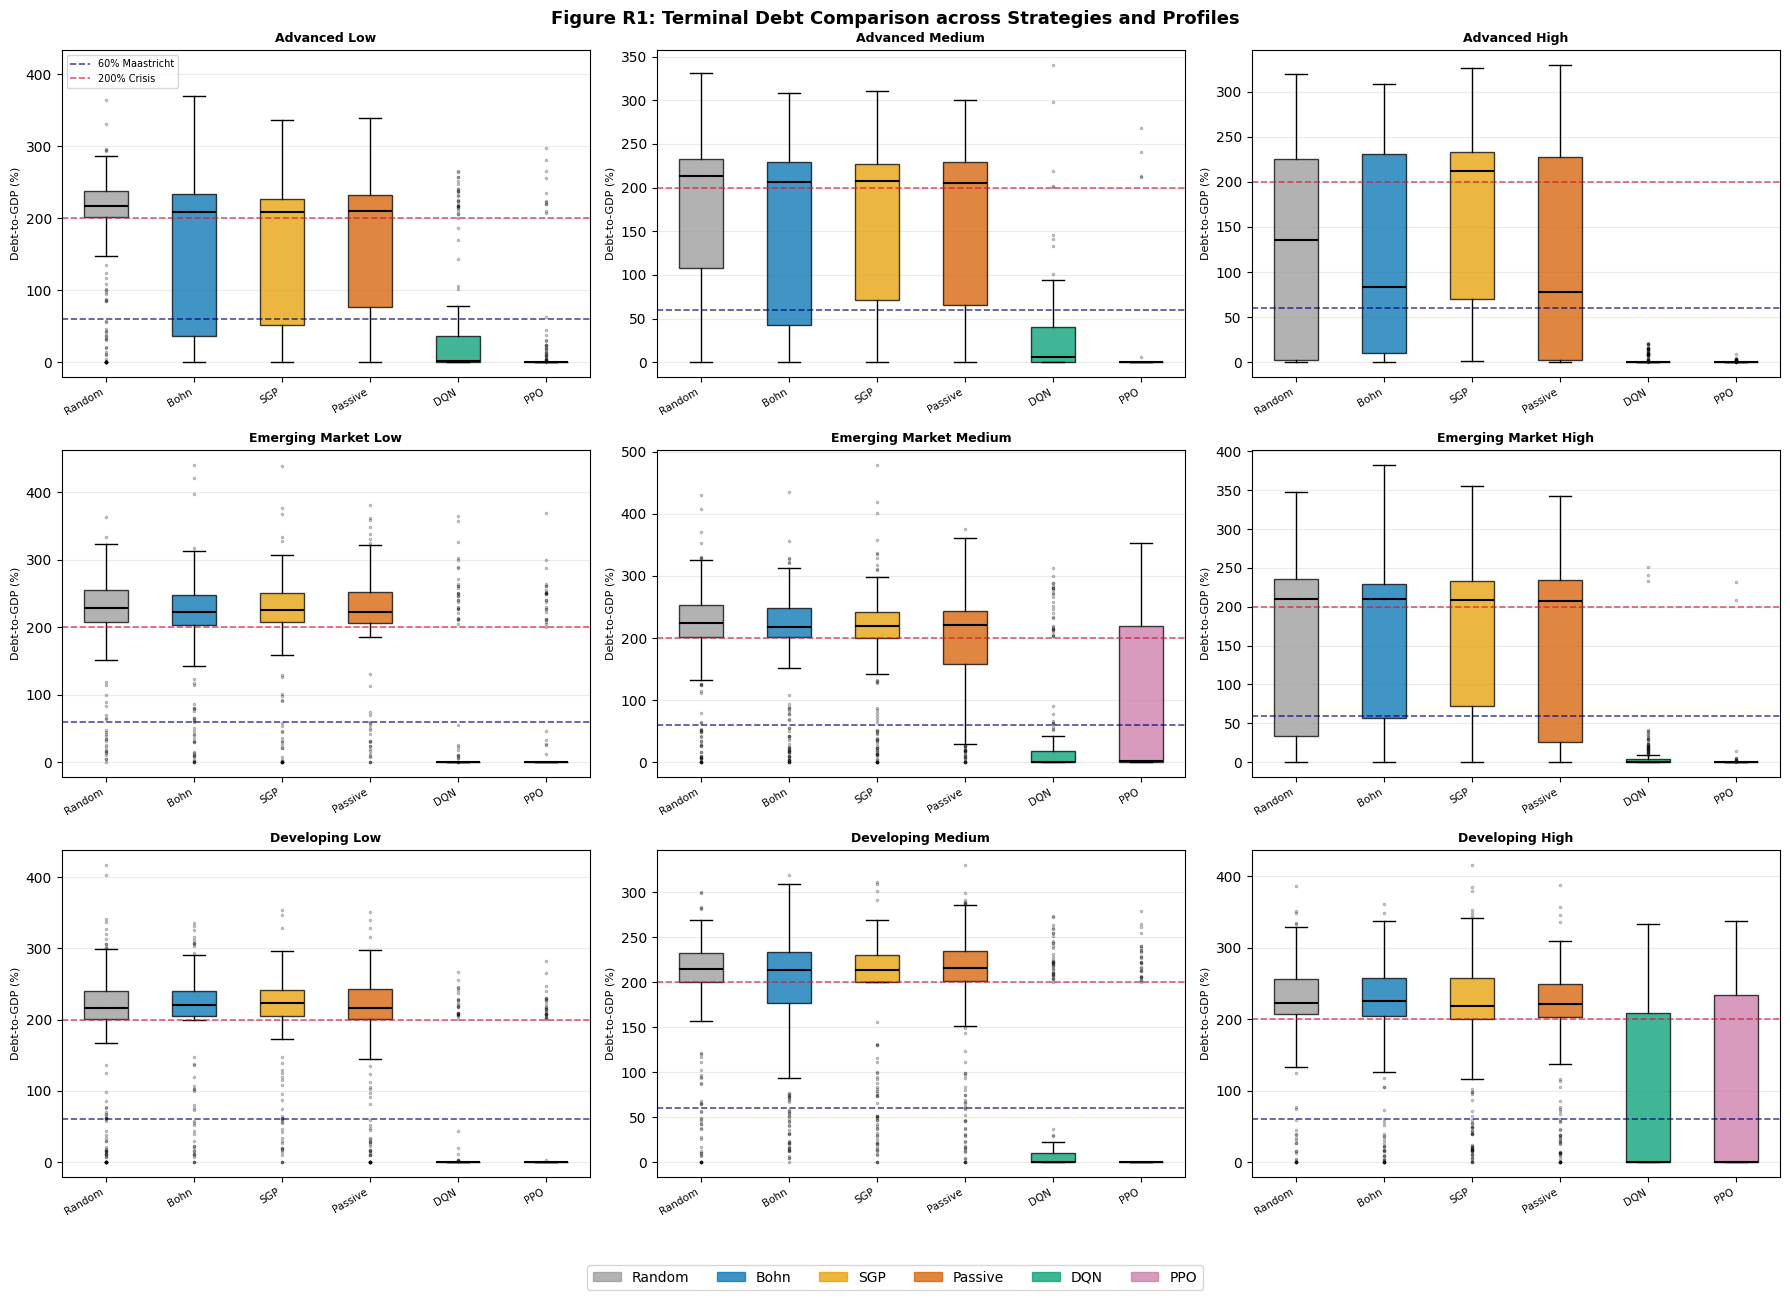

Saved fig_R1_terminal_debt_boxplots


In [11]:
# ── Figure R1: Terminal Debt Comparison (Box Plots) ────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
profile_order = [
    'Advanced_Low', 'Advanced_Medium', 'Advanced_High',
    'Emerging_Market_Low', 'Emerging_Market_Medium', 'Emerging_Market_High',
    'Developing_Low', 'Developing_Medium', 'Developing_High',
]

for idx, profile in enumerate(profile_order):
    ax = axes.flatten()[idx]
    data = []
    labels = []
    colors = []
    for strat in STRATEGY_NAMES:
        if strat in results.get(profile, {}):
            data.append(results[profile][strat]['terminal_debts'])
            labels.append(strat)
            colors.append(STRATEGY_COLORS[strat])

    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    widths=0.5, showfliers=True,
                    flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    ax.axhline(60, color='navy', linestyle='--', linewidth=1.2, alpha=0.7, label='60% Maastricht')
    ax.axhline(200, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7, label='200% Crisis')
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=7.5, rotation=30, ha='right')
    ax.set_ylabel('Debt-to-GDP (%)', fontsize=8)
    ax.set_title(profile.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.25)
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Figure R1: Terminal Debt Comparison across Strategies and Profiles',
             fontsize=13, fontweight='bold')

# Shared strategy legend
legend_handles = [
    mpatches.Patch(color=STRATEGY_COLORS[s], label=s, alpha=0.75)
    for s in STRATEGY_NAMES
]
fig.legend(handles=legend_handles, ncol=6, loc='lower center',
           bbox_to_anchor=(0.5, -0.01), fontsize=10, frameon=True)
plt.tight_layout(rect=[0, 0.04, 1, 1])

for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_R1_terminal_debt_boxplots.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved fig_R1_terminal_debt_boxplots')

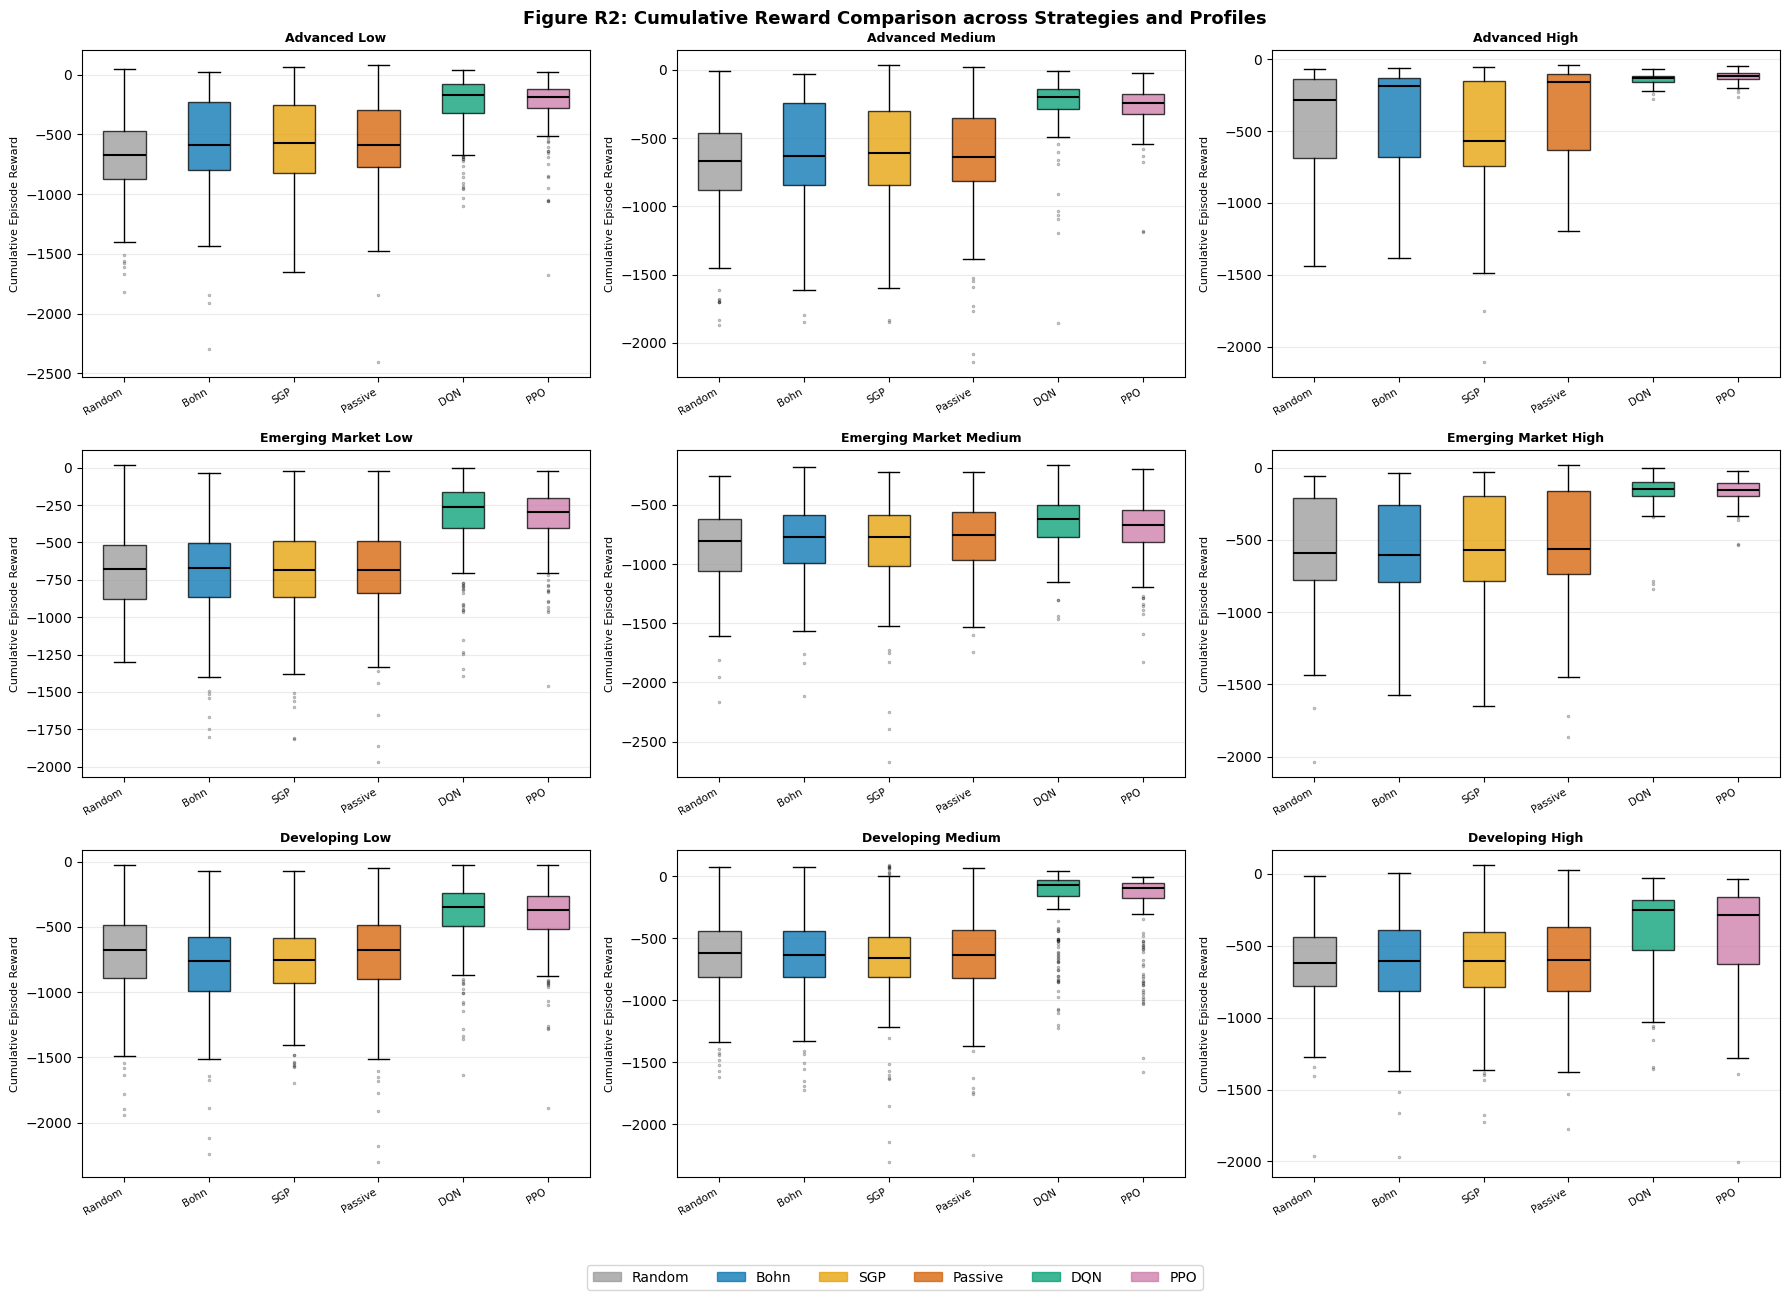

Saved fig_R2_cumulative_reward_boxplots


In [12]:
# ── Figure R2: Cumulative Reward Comparison (Box Plots) ───────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 13))

for idx, profile in enumerate(profile_order):
    ax = axes.flatten()[idx]
    data = []
    labels = []
    colors = []
    for strat in STRATEGY_NAMES:
        if strat in results.get(profile, {}):
            data.append(results[profile][strat]['cumulative_rewards'])
            labels.append(strat)
            colors.append(STRATEGY_COLORS[strat])

    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    widths=0.5, showfliers=True,
                    flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=7.5, rotation=30, ha='right')
    ax.set_ylabel('Cumulative Episode Reward', fontsize=8)
    ax.set_title(profile.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('Figure R2: Cumulative Reward Comparison across Strategies and Profiles',
             fontsize=13, fontweight='bold')
fig.legend(handles=legend_handles, ncol=6, loc='lower center',
           bbox_to_anchor=(0.5, -0.01), fontsize=10, frameon=True)
plt.tight_layout(rect=[0, 0.04, 1, 1])

for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_R2_cumulative_reward_boxplots.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_R2_cumulative_reward_boxplots')

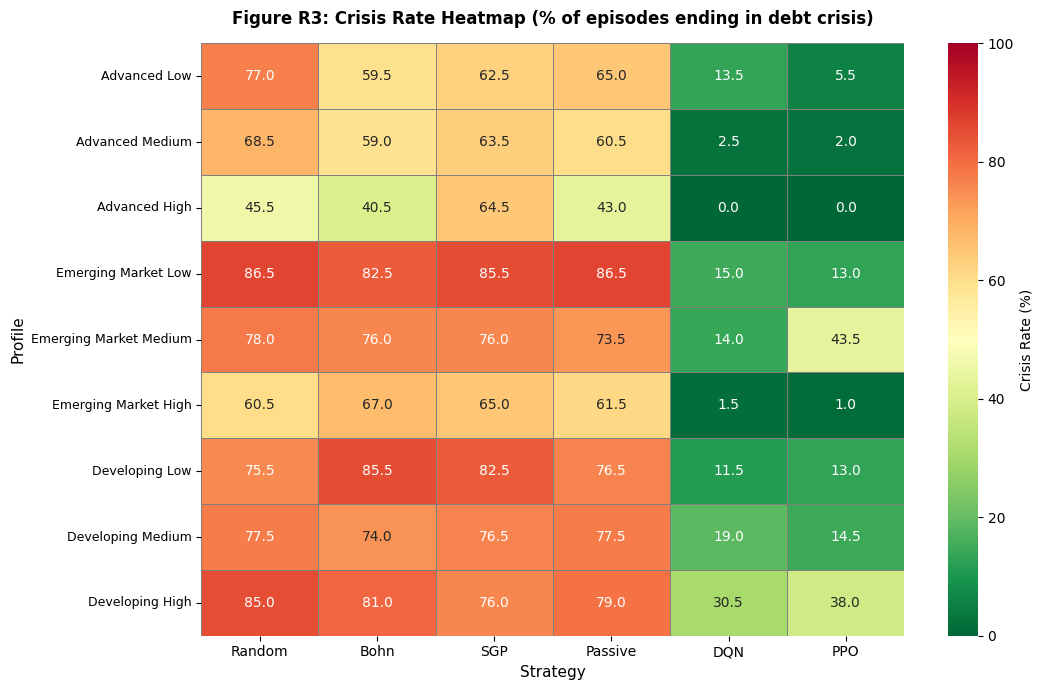

Saved fig_R3_crisis_rate_heatmap


In [13]:
# ── Figure R3: Crisis Rate Heatmap ─────────────────────────────────────────
crisis_matrix = []
for profile in profile_order:
    row = []
    for strat in STRATEGY_NAMES:
        if strat in results.get(profile, {}):
            row.append(results[profile][strat]['crisis_rate'])
        else:
            row.append(np.nan)
    crisis_matrix.append(row)

crisis_df = pd.DataFrame(
    crisis_matrix,
    index=[p.replace('_', ' ') for p in profile_order],
    columns=STRATEGY_NAMES,
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    crisis_df,
    annot=True, fmt='.1f', cmap='RdYlGn_r',
    vmin=0, vmax=100,
    linewidths=0.5, linecolor='grey',
    cbar_kws={'label': 'Crisis Rate (%)'},
    ax=ax,
)
ax.set_title('Figure R3: Crisis Rate Heatmap (% of episodes ending in debt crisis)',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Strategy', fontsize=11)
ax.set_ylabel('Profile', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()

for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_R3_crisis_rate_heatmap.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_R3_crisis_rate_heatmap')

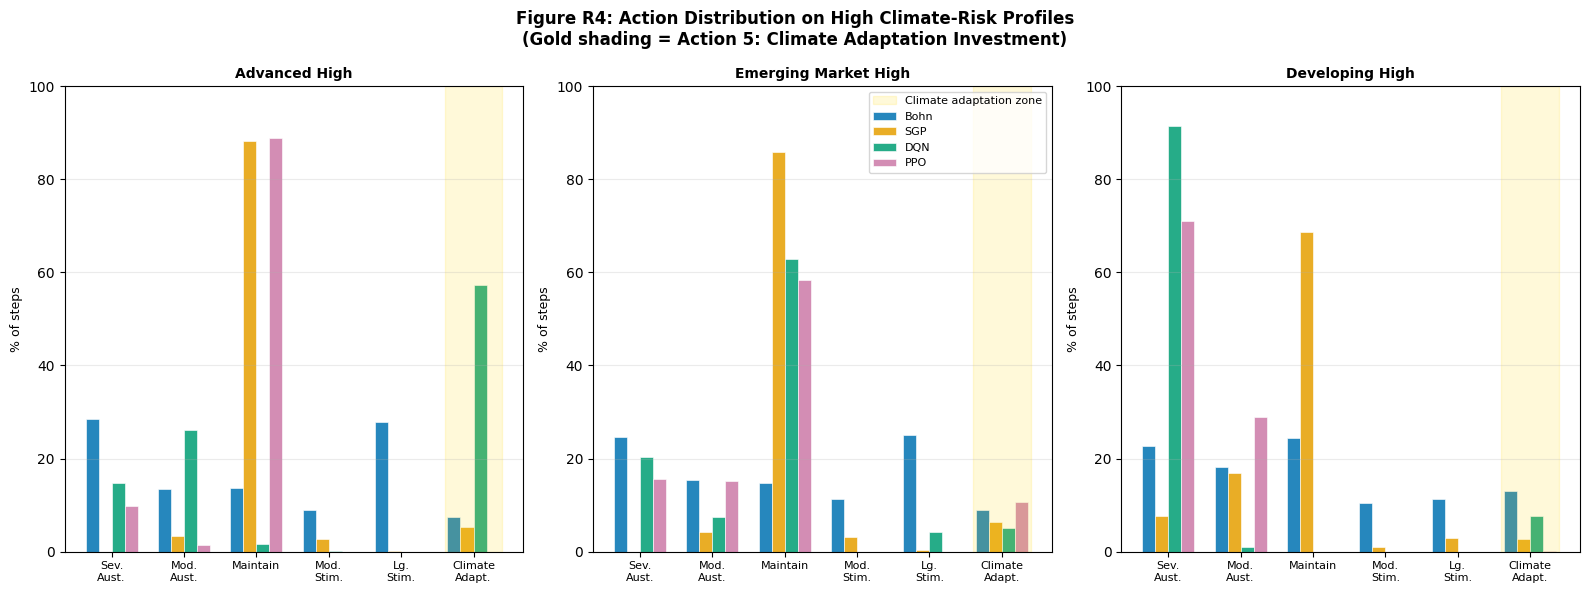

Saved fig_R4_action_distributions_high_risk

Action 5 (Climate Adaptation) usage on High-risk profiles:
  Bohn on Advanced_High: 7.5%
  SGP on Advanced_High: 5.4%
  DQN on Advanced_High: 57.3%
  PPO on Advanced_High: 0.0%
  Bohn on Emerging_Market_High: 9.0%
  SGP on Emerging_Market_High: 6.4%
  DQN on Emerging_Market_High: 5.0%
  PPO on Emerging_Market_High: 10.7%
  Bohn on Developing_High: 13.1%
  SGP on Developing_High: 2.7%
  DQN on Developing_High: 7.6%
  PPO on Developing_High: 0.2%


In [14]:
# ── Figure R4: Action Distribution for High-Risk Profiles ─────────────────
# Key question: does RL learn to use action 5 (climate adaptation) more than benchmarks?
high_risk_profiles = ['Advanced_High', 'Emerging_Market_High', 'Developing_High']
focus_strategies   = ['Bohn', 'SGP', 'DQN', 'PPO']

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
x = np.arange(6)
n = len(focus_strategies)
width = 0.18

for col_idx, profile in enumerate(high_risk_profiles):
    ax = axes[col_idx]
    pres = results.get(profile, {})
    for i, strat in enumerate(focus_strategies):
        if strat not in pres:
            continue
        ad = pres[strat]['action_distribution']
        vals = [ad.get(a, 0.0) for a in range(6)]
        offset = (i - (n - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width,
                      label=strat,
                      color=STRATEGY_COLORS[strat],
                      alpha=0.85,
                      edgecolor='white', linewidth=0.5)

    ax.set_xticks(x)
    short_names = ['Sev.\nAust.', 'Mod.\nAust.', 'Maintain', 'Mod.\nStim.', 'Lg.\nStim.', 'Climate\nAdapt.']
    ax.set_xticklabels(short_names, fontsize=8)
    ax.set_ylabel('% of steps', fontsize=9)
    ax.set_title(profile.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.25)
    ax.set_ylim(0, 100)
    # Highlight action 5 column
    ax.axvspan(4.6, 5.4, color='gold', alpha=0.15, label='Climate adaptation zone')
    if col_idx == 1:
        ax.legend(fontsize=8, loc='upper right')

fig.suptitle(
    'Figure R4: Action Distribution on High Climate-Risk Profiles\n'
    '(Gold shading = Action 5: Climate Adaptation Investment)',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()

for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_R4_action_distributions_high_risk.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_R4_action_distributions_high_risk')

# Print action-5 usage summary
print()
print('Action 5 (Climate Adaptation) usage on High-risk profiles:')
for profile in high_risk_profiles:
    pres = results.get(profile, {})
    for strat in focus_strategies:
        if strat in pres:
            pct = pres[strat]['action_distribution'].get(5, 0.0)
            print(f'  {strat} on {profile}: {pct:.1f}%')

  Bohn: 7 steps, final debt=228.2%
  Passive: 6 steps, final debt=232.8%
  DQN: 9 steps, final debt=261.4%
  PPO: 8 steps, final debt=213.3%


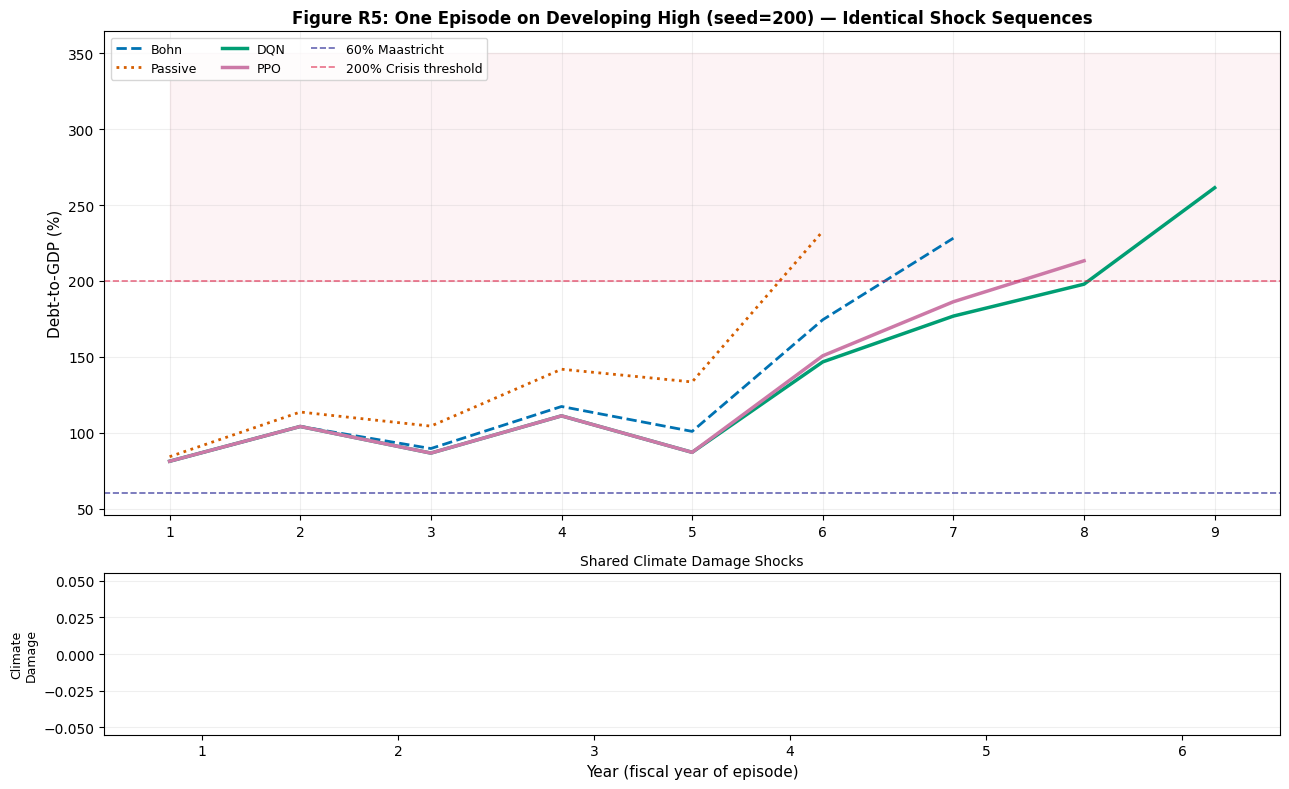

Saved fig_R5_trajectory_comparison


In [15]:
# ── Figure R5: Single Episode Trajectory Comparison (Developing_High) ──────
# All strategies face IDENTICAL shock sequences (same env seed = same RNG state).
TRAJ_PROFILE  = 'Developing_High'
TRAJ_SEED     = 200   # distinct from EVAL_SEED to get a fresh interesting episode
traj_strats   = ['Bohn', 'Passive', 'DQN', 'PPO']
traj_linewidths = {'Bohn': 2, 'Passive': 2, 'DQN': 2.5, 'PPO': 2.5}
traj_linestyles = {'Bohn': '--', 'Passive': ':', 'DQN': '-', 'PPO': '-'}

traj_results = {}
for strat in traj_strats:
    env = SovereignRiskEnv(
        profile=TRAJ_PROFILE,
        config_path=CONFIG_PATH,
        scaling_path=SCALING_PATH,
        seed=TRAJ_SEED,
    )
    obs, info = env.reset()

    if strat == 'DQN':
        policy = DQNPolicy(dqn_agents[TRAJ_PROFILE])
    elif strat == 'PPO':
        policy = PPOPolicy(ppo_agents[TRAJ_PROFILE])
    elif strat == 'Bohn':
        policy = calibrated_bohn[TRAJ_PROFILE]
    else:
        policy = PassiveStressTest()
    policy.reset()

    debt_path, growth_path, climate_path, action_path = [], [], [], []
    done = False
    while not done:
        action = policy.select_action(obs, info)
        obs, reward, terminated, truncated, info = env.step(action)
        raw = info.get('raw_state', {})
        debt_path.append(raw.get('debt', 0.0))
        growth_path.append(raw.get('growth', 0.0))
        climate_path.append(info.get('climate_damage', 0.0))
        action_path.append(action)
        done = terminated or truncated
    env.close()
    traj_results[strat] = {
        'debt': debt_path, 'growth': growth_path,
        'climate': climate_path, 'actions': action_path,
    }
    print(f'  {strat}: {len(debt_path)} steps, final debt={debt_path[-1]:.1f}%')

# Use Passive climate path as the shared reference
climate_ref = traj_results['Passive']['climate']
steps_ref   = range(1, len(climate_ref) + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=False)

# Top panel: debt trajectories
for strat in traj_strats:
    debt = traj_results[strat]['debt']
    steps = range(1, len(debt) + 1)
    ax1.plot(
        steps, debt,
        color=STRATEGY_COLORS[strat],
        linewidth=traj_linewidths[strat],
        linestyle=traj_linestyles[strat],
        label=strat,
    )
ax1.axhline(60,  color='navy',   linestyle='--', linewidth=1.2, alpha=0.6, label='60% Maastricht')
ax1.axhline(200, color='crimson', linestyle='--', linewidth=1.2, alpha=0.6, label='200% Crisis threshold')
ax1.fill_between(range(1, 32), 200, 350, color='crimson', alpha=0.05)
ax1.set_ylabel('Debt-to-GDP (%)', fontsize=11)
ax1.set_title(
    f'Figure R5: One Episode on {TRAJ_PROFILE.replace("_", " ")} '
    f'(seed={TRAJ_SEED}) — Identical Shock Sequences',
    fontsize=12, fontweight='bold',
)
ax1.legend(fontsize=9, ncol=3, loc='upper left')
ax1.grid(alpha=0.2)
ax1.set_xlim(0.5, max(len(traj_results[s]['debt']) for s in traj_strats) + 0.5)

# Bottom panel: climate damage events (shared across strategies)
climate_steps = range(1, len(climate_ref) + 1)
ax2.bar(climate_steps, climate_ref, color='#9467bd', alpha=0.75, width=0.6)
ax2.set_xlabel('Year (fiscal year of episode)', fontsize=11)
ax2.set_ylabel('Climate\nDamage', fontsize=9)
ax2.set_title('Shared Climate Damage Shocks', fontsize=10)
ax2.grid(axis='y', alpha=0.2)
ax2.set_xlim(0.5, len(climate_ref) + 0.5)

plt.tight_layout()
for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_R5_trajectory_comparison.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_R5_trajectory_comparison')

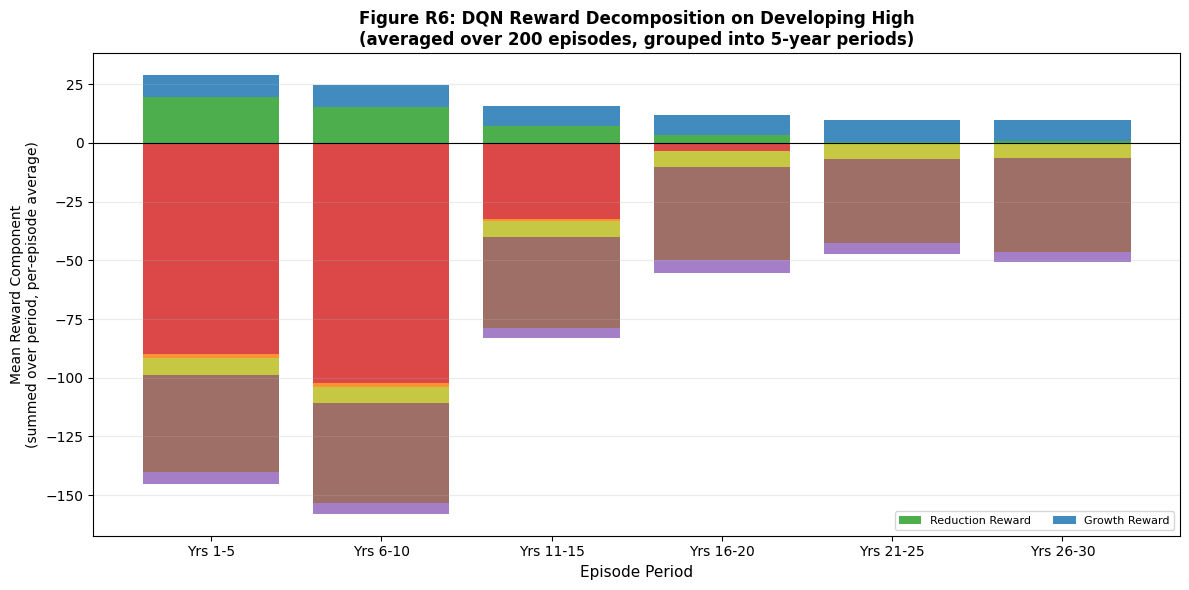

Saved fig_R6_reward_decomposition


In [16]:
# ── Figure R6: Reward Decomposition for DQN on Developing_High ────────────
# Collect per-step reward component data averaged over 200 episodes.

R6_PROFILE  = 'Developing_High'
R6_EPISODES = 200
MAX_STEPS   = 30

# step_data[component][step] = list of values across episodes
step_data = {k: [[] for _ in range(MAX_STEPS)] for k in REWARD_COMPONENTS}

r6_env = SovereignRiskEnv(
    profile=R6_PROFILE,
    config_path=CONFIG_PATH,
    scaling_path=SCALING_PATH,
    seed=EVAL_SEED,
)
r6_policy = DQNPolicy(dqn_agents[R6_PROFILE])

for ep in range(R6_EPISODES):
    obs, info = r6_env.reset()
    r6_policy.reset()
    step = 0
    done = False
    while not done and step < MAX_STEPS:
        action = r6_policy.select_action(obs, info)
        obs, reward, terminated, truncated, info = r6_env.step(action)
        comps = info.get('reward_components', {})
        for k in REWARD_COMPONENTS:
            step_data[k][step].append(comps.get(k, 0.0))
        step += 1
        done = terminated or truncated
r6_env.close()

# Mean per step (average across episodes that reached that step)
step_means = {
    k: np.array([np.mean(v) if v else 0.0 for v in step_data[k]])
    for k in REWARD_COMPONENTS
}

# Group into 5-year periods
period_labels = ['Yrs 1-5', 'Yrs 6-10', 'Yrs 11-15',
                 'Yrs 16-20', 'Yrs 21-25', 'Yrs 26-30']
period_sums = {k: [] for k in REWARD_COMPONENTS}
for k in REWARD_COMPONENTS:
    for i in range(6):
        period_sums[k].append(float(np.sum(step_means[k][i*5:(i+1)*5])))

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
xpos = np.arange(6)
bottom_pos = np.zeros(6)
bottom_neg = np.zeros(6)

for k in REWARD_COMPONENTS:
    vals = np.array(period_sums[k])
    pos_vals = np.where(vals >= 0, vals, 0)
    neg_vals = np.where(vals < 0,  vals, 0)
    label = k.replace('_', ' ').title()
    if pos_vals.any():
        ax.bar(xpos, pos_vals, bottom=bottom_pos,
               color=COMPONENT_COLORS[k], alpha=0.85, label=label)
        bottom_pos += pos_vals
    if neg_vals.any():
        ax.bar(xpos, neg_vals, bottom=bottom_neg,
               color=COMPONENT_COLORS[k], alpha=0.85)
        bottom_neg += neg_vals

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(xpos)
ax.set_xticklabels(period_labels, fontsize=10)
ax.set_xlabel('Episode Period', fontsize=11)
ax.set_ylabel('Mean Reward Component\n(summed over period, per-episode average)', fontsize=10)
ax.set_title(
    f'Figure R6: DQN Reward Decomposition on {R6_PROFILE.replace("_", " ")}\n'
    f'(averaged over {R6_EPISODES} episodes, grouped into 5-year periods)',
    fontsize=12, fontweight='bold',
)
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()

for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_R6_reward_decomposition.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_R6_reward_decomposition')

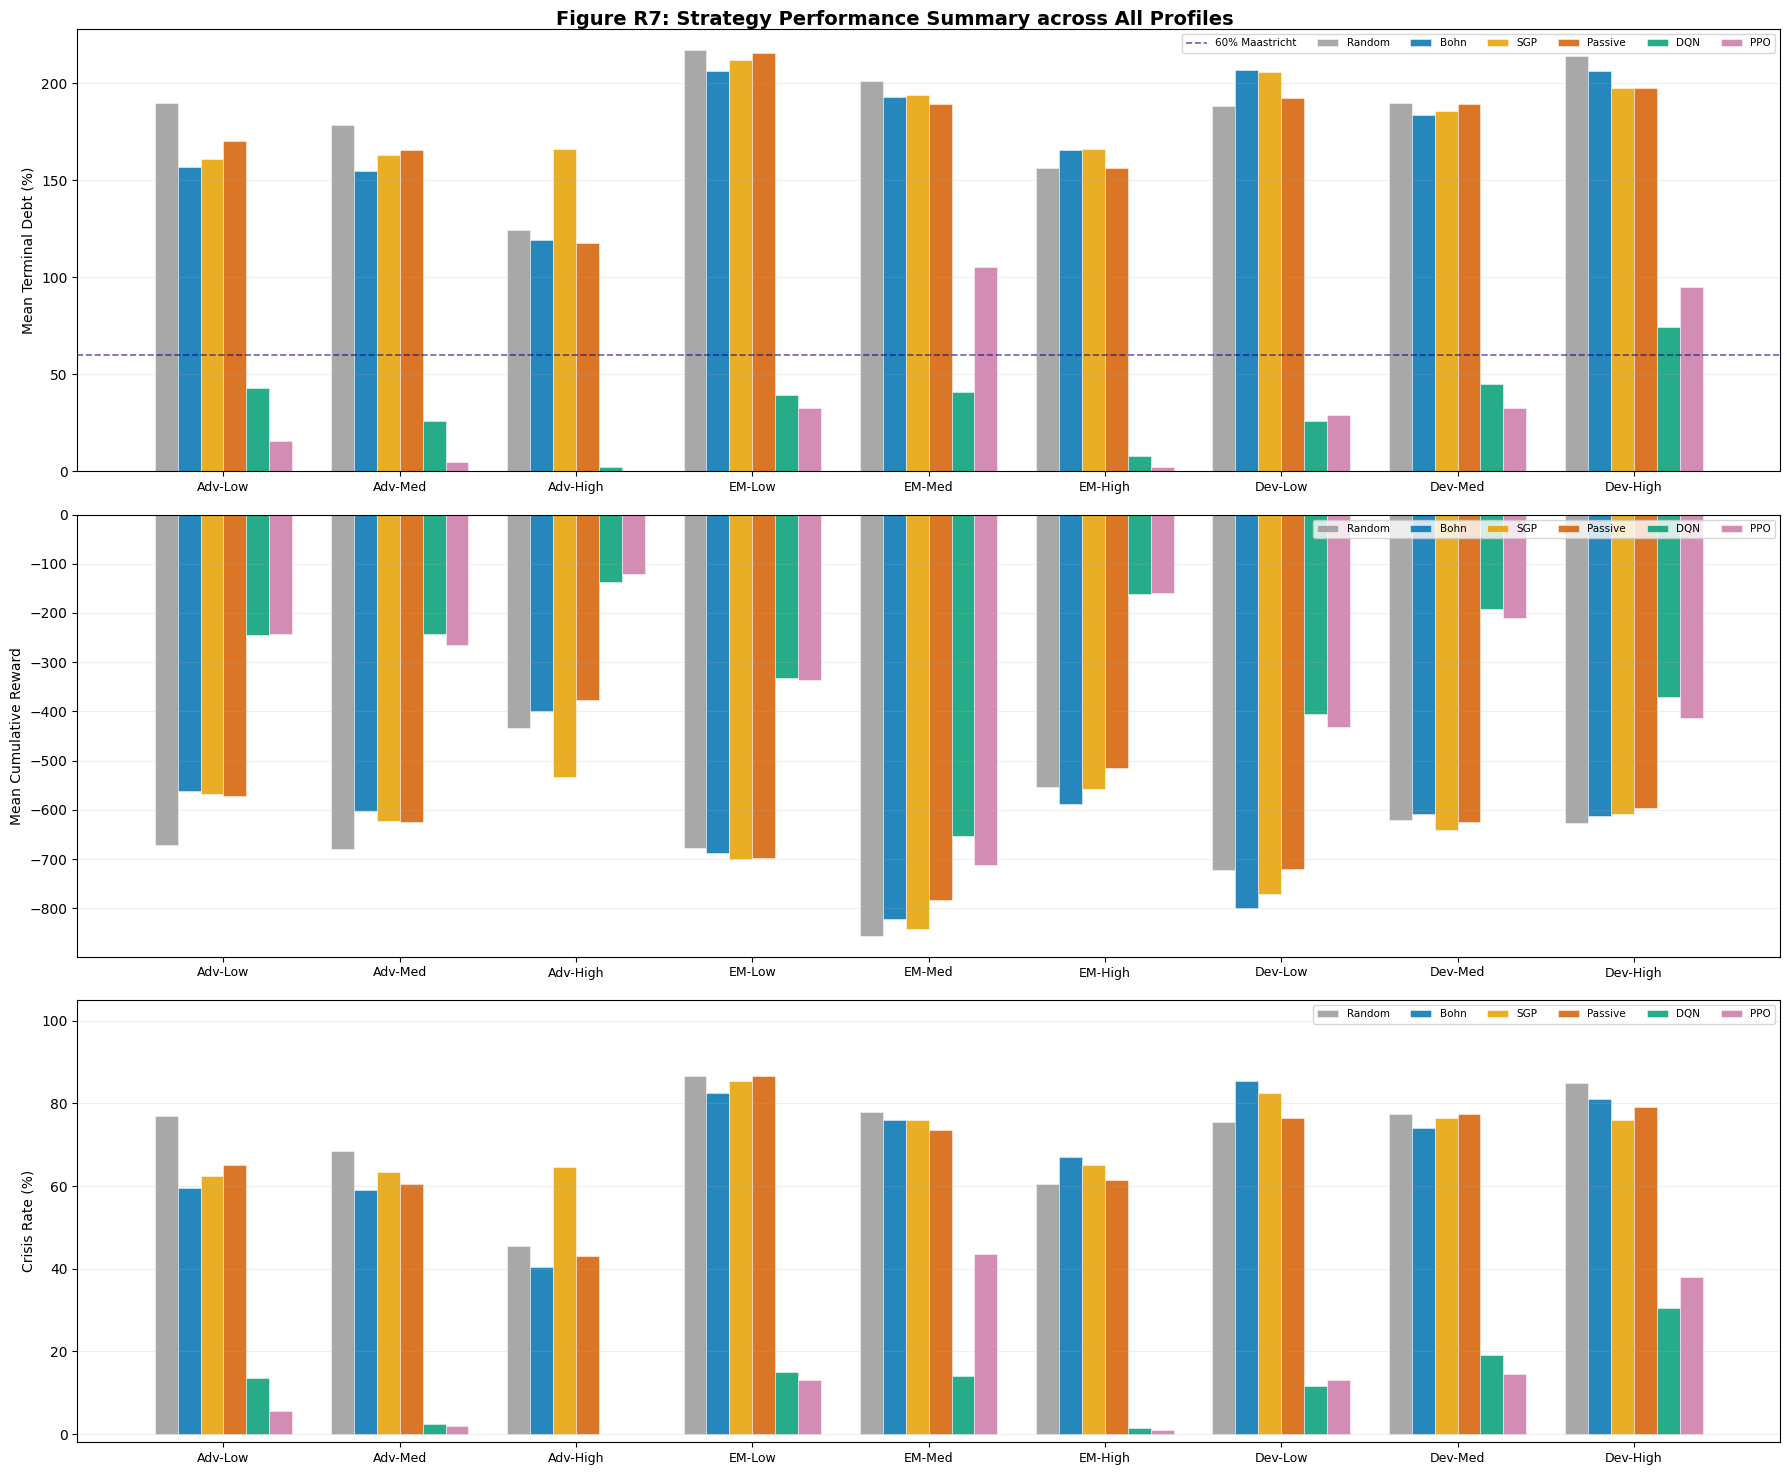

Saved fig_R7_strategy_summary


In [17]:
# ── Figure R7: Strategy Performance Summary (3-panel) ─────────────────────
metric_keys    = ['mean_terminal_debt', 'mean_cumulative_reward', 'crisis_rate']
metric_labels  = ['Mean Terminal Debt (%)', 'Mean Cumulative Reward', 'Crisis Rate (%)']

fig, axes = plt.subplots(3, 1, figsize=(18, 15))

short_profiles = [
    'Adv-Low', 'Adv-Med', 'Adv-High',
    'EM-Low',  'EM-Med',  'EM-High',
    'Dev-Low', 'Dev-Med', 'Dev-High',
]
n_profiles   = len(profile_order)
n_strategies = len(STRATEGY_NAMES)
bar_width     = 0.13
x = np.arange(n_profiles)

for row, (metric, ylabel) in enumerate(zip(metric_keys, metric_labels)):
    ax = axes[row]
    for si, strat in enumerate(STRATEGY_NAMES):
        vals = []
        for profile in profile_order:
            if strat in results.get(profile, {}):
                vals.append(results[profile][strat][metric])
            else:
                vals.append(0.0)
        offset = (si - (n_strategies - 1) / 2) * bar_width
        ax.bar(x + offset, vals, bar_width,
               color=STRATEGY_COLORS[strat],
               label=strat, alpha=0.85,
               edgecolor='white', linewidth=0.4)

    if metric == 'mean_terminal_debt':
        ax.axhline(60, color='navy', linestyle='--', linewidth=1.2,
                   alpha=0.6, label='60% Maastricht')
    if metric == 'crisis_rate':
        ax.set_ylim(-2, 105)

    ax.set_xticks(x)
    ax.set_xticklabels(short_profiles, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=7.5, ncol=7, loc='upper right')
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Figure R7: Strategy Performance Summary across All Profiles',
             fontsize=14, fontweight='bold')
plt.tight_layout()

for ext in ['png', 'svg']:
    plt.savefig(f'{FIGURES_DIR}/fig_R7_strategy_summary.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print('Saved fig_R7_strategy_summary')

## Part 4: Cross-Algorithmic Consistency Check

One of the four layers of the validation protocol. High consistency between DQN and PPO (independent implementations) strengthens confidence in the learned fiscal policy.

In [18]:
# ── 4a. Policy agreement rate ──────────────────────────────────────────────
# Run 100 episodes simultaneously with DQN and PPO, record action agreement.
# The environment is advanced using DQN's action.

agreement_rates = {}
for profile in PROFILES:
    if profile not in dqn_agents or profile not in ppo_agents:
        print(f'  Skipping {profile}: missing model')
        continue
    env = SovereignRiskEnv(
        profile=profile,
        config_path=CONFIG_PATH,
        scaling_path=SCALING_PATH,
        seed=EVAL_SEED,
    )
    agreements = 0
    total = 0
    for _ in range(100):
        obs, info = env.reset()
        done = False
        while not done:
            dqn_action = dqn_agents[profile].select_action(obs, evaluate=True)
            ppo_action = int(ppo_agents[profile].predict(obs, deterministic=True)[0])
            if dqn_action == ppo_action:
                agreements += 1
            total += 1
            obs, _, term, trunc, info = env.step(dqn_action)   # advance with DQN
            done = term or trunc
    env.close()
    agreement_rates[profile] = agreements / total * 100
    rate = agreement_rates[profile]
    tier = 'STRONG (>70%)' if rate > 70 else ('MODERATE (40-70%)' if rate > 40 else 'WEAK (<40%)')
    print(f'  {profile:<30}: {rate:.1f}%  [{tier}]')

print(f'\nMean agreement rate: {np.mean(list(agreement_rates.values())):.1f}%')
print()
print('Interpretation:')
print('  >70%: strong consistency -- learned policy robust across algorithms')
print('  40-70%: moderate consistency -- structural agreement but different nuances')
print('  <40%: weak consistency -- algorithms found different local optima')

  Advanced_Low                  : 35.3%  [WEAK (<40%)]


Profile 'Advanced_High' is sparse (2 countries). The following null parameters have been substituted with Advanced_Low fallback values: {'initial_primary_balance': -0.106, 'initial_interest_rate': 5.8217, 'initial_risk_premium': 4.8411, 'rate_base': 5.8217}


  Advanced_Medium               : 27.2%  [WEAK (<40%)]


Profile 'Emerging_Market_Low': calibrated climate_fiscal_cost is +0.547 (wrong sign — implies disasters improve fiscal balance). Overriding to -0.5 for all Emerging Market profiles. See config.py for methodology rationale.


  Advanced_High                 : 4.1%  [WEAK (<40%)]


...

  Emerging_Market_Medium        : 26.4%  [WEAK (<40%)]


  Emerging_Market_High          : 53.6%  [MODERATE (40-70%)]


  Developing_Low                : 59.5%  [MODERATE (40-70%)]


  Developing_Medium             : 50.4%  [MODERATE (40-70%)]


  Developing_High               : 74.0%  [STRONG (>70%)]

Mean agreement rate: 41.9%

Interpretation:
  >70%: strong consistency -- learned policy robust across algorithms
  40-70%: moderate consistency -- structural agreement but different nuances
  <40%: weak consistency -- algorithms found different local optima


In [19]:
# ── 4b. Rank correlation across profiles ──────────────────────────────────
complete_profiles = [
    p for p in PROFILES
    if 'DQN' in results.get(p, {}) and 'PPO' in results.get(p, {})
]

dqn_debts   = [results[p]['DQN']['mean_terminal_debt']     for p in complete_profiles]
ppo_debts   = [results[p]['PPO']['mean_terminal_debt']     for p in complete_profiles]
dqn_rewards = [results[p]['DQN']['mean_cumulative_reward'] for p in complete_profiles]
ppo_rewards = [results[p]['PPO']['mean_cumulative_reward'] for p in complete_profiles]
dqn_crises  = [results[p]['DQN']['crisis_rate']            for p in complete_profiles]
ppo_crises  = [results[p]['PPO']['crisis_rate']            for p in complete_profiles]

rho_debt,   p_debt   = spearmanr(dqn_debts,   ppo_debts)
rho_reward, p_reward = spearmanr(dqn_rewards, ppo_rewards)
rho_crisis, p_crisis = spearmanr(dqn_crises,  ppo_crises)

print('=== Spearman Rank Correlations: DQN vs PPO across 9 profiles ===')
print(f'  Terminal debt:      rho={rho_debt:.3f}  p={p_debt:.4f}')
print(f'  Cumulative reward:  rho={rho_reward:.3f}  p={p_reward:.4f}')
print(f'  Crisis rate:        rho={rho_crisis:.3f}  p={p_crisis:.4f}')
print()
print('Interpretation: rho > 0.8 means both algorithms rank profiles similarly')
print('in terms of difficulty and performance, even if exact actions differ.')

# ── 4c. Save consistency results ──────────────────────────────────────────
consistency = {
    'agreement_rates': {p: round(v, 2) for p, v in agreement_rates.items()},
    'mean_agreement_rate': round(float(np.mean(list(agreement_rates.values()))), 2),
    'rank_correlations': {
        'terminal_debt':      {'rho': round(rho_debt, 4),   'p_value': round(p_debt, 4)},
        'cumulative_reward':  {'rho': round(rho_reward, 4), 'p_value': round(p_reward, 4)},
        'crisis_rate':        {'rho': round(rho_crisis, 4), 'p_value': round(p_crisis, 4)},
    },
    'n_profiles_in_correlation': len(complete_profiles),
}
with open(f'{RESULTS_DIR}/cross_algorithmic_consistency.json', 'w') as f:
    json.dump(consistency, f, indent=2)
print('Saved cross_algorithmic_consistency.json')

=== Spearman Rank Correlations: DQN vs PPO across 9 profiles ===
  Terminal debt:      rho=0.817  p=0.0072
  Cumulative reward:  rho=0.983  p=0.0000
  Crisis rate:        rho=0.862  p=0.0028

Interpretation: rho > 0.8 means both algorithms rank profiles similarly
in terms of difficulty and performance, even if exact actions differ.
Saved cross_algorithmic_consistency.json


## Part 5: Stress Test Comparison

RL agents evaluated under the NGFS Hot House World 2× climate stress scenario. The key question: **how much better do RL agents perform than inaction when climate risk doubles?** This represents the "value of active fiscal policy under climate stress."

In [20]:
# ── 5a. RL agents under 2x climate stress ─────────────────────────────────
STRESS_FACTOR   = 2.0
STRESS_EPISODES = 100

stress_results = {}
for profile in PROFILES:
    print(f'\nStress test: {profile}')
    stress_strategies = {'Passive': PassiveStressTest()}
    if profile in dqn_agents:
        stress_strategies['DQN'] = DQNPolicy(dqn_agents[profile])
    if profile in ppo_agents:
        stress_strategies['PPO'] = PPOPolicy(ppo_agents[profile])

    for name, policy in stress_strategies.items():
        r = evaluate_strategy(
            policy, profile, STRESS_EPISODES, EVAL_SEED,
            climate_stress_factor=STRESS_FACTOR,
        )
        stress_results[(profile, name)] = r
        print(
            f'  {name:>8s}: debt={r["mean_terminal_debt"]:>7.1f}%  '
            f'reward={r["mean_cumulative_reward"]:>8.1f}  '
            f'crises={r["crisis_rate"]:>5.1f}%'
        )

print('\nStress test complete.')


Stress test: Advanced_Low
   Passive: debt=  194.1%  reward=  -663.0  crises= 79.0%


       DQN: debt=   57.1%  reward=  -302.3  crises= 18.0%


       PPO: debt=   17.1%  reward=  -253.9  crises=  7.0%

Stress test: Advanced_Medium
   Passive: debt=  176.4%  reward=  -653.5  crises= 61.0%


       DQN: debt=   32.0%  reward=  -299.8  crises=  5.0%


Profile 'Advanced_High' is sparse (2 countries). The following null parameters have been substituted with Advanced_Low fallback values: {'initial_primary_balance': -0.106, 'initial_interest_rate': 5.8217, 'initial_risk_premium': 4.8411, 'rate_base': 5.8217}


...

       PPO: debt=   26.9%  reward=  -529.8  crises= 12.0%

Stress test: Developing_Medium
   Passive: debt=  198.5%  reward=  -661.9  crises= 83.0%


       DQN: debt=   50.1%  reward=  -244.7  crises= 21.0%


       PPO: debt=   49.3%  reward=  -283.5  crises= 22.0%

Stress test: Developing_High
   Passive: debt=  200.7%  reward=  -620.2  crises= 78.0%


       DQN: debt=   67.2%  reward=  -438.1  crises= 28.0%


       PPO: debt=   86.4%  reward=  -435.1  crises= 35.0%

Stress test complete.


In [21]:
# ── 5b. Stress test results table ─────────────────────────────────────────
stress_rows = []
for profile in PROFILES:
    for strat in ['Passive', 'DQN', 'PPO']:
        key = (profile, strat)
        if key not in stress_results:
            continue
        r = stress_results[key]
        stress_rows.append({
            'Profile':              profile,
            'Strategy':             strat,
            'Mean Terminal Debt':   round(r['mean_terminal_debt'], 1),
            'Mean Cumul. Reward':   round(r['mean_cumulative_reward'], 1),
            'Crisis Rate (%)':      round(r['crisis_rate'], 1),
        })

stress_df = pd.DataFrame(stress_rows)
stress_df.to_csv(f'{RESULTS_DIR}/stress_test_results.csv', index=False)
print('Saved stress_test_results.csv')
print(stress_df.to_string(index=False))

print()
print('=== Value of Active Policy under 2x Climate Stress ===')
print(f'  (compared to Passive benchmark, {STRESS_EPISODES} episodes per profile)')
print(f'  {"Profile":<30}  {"DQN debt diff":>14}  {"PPO debt diff":>14}  {"DQN reward lift":>16}  {"PPO reward lift":>16}')
print('-' * 95)
for profile in PROFILES:
    passive_debt   = stress_results.get((profile, 'Passive'), {}).get('mean_terminal_debt',   float('nan'))
    passive_reward = stress_results.get((profile, 'Passive'), {}).get('mean_cumulative_reward', float('nan'))
    dqn_debt       = stress_results.get((profile, 'DQN'),     {}).get('mean_terminal_debt',   float('nan'))
    dqn_reward     = stress_results.get((profile, 'DQN'),     {}).get('mean_cumulative_reward', float('nan'))
    ppo_debt       = stress_results.get((profile, 'PPO'),     {}).get('mean_terminal_debt',   float('nan'))
    ppo_reward     = stress_results.get((profile, 'PPO'),     {}).get('mean_cumulative_reward', float('nan'))
    print(
        f'  {profile:<30}  {dqn_debt-passive_debt:>+14.1f}  {ppo_debt-passive_debt:>+14.1f}  '
        f'{dqn_reward-passive_reward:>+16.1f}  {ppo_reward-passive_reward:>+16.1f}'
    )

Saved stress_test_results.csv
               Profile Strategy  Mean Terminal Debt  Mean Cumul. Reward  Crisis Rate (%)
          Advanced_Low  Passive               194.1              -663.0             79.0
          Advanced_Low      DQN                57.1              -302.3             18.0
          Advanced_Low      PPO                17.1              -253.9              7.0
       Advanced_Medium  Passive               176.4              -653.5             61.0
       Advanced_Medium      DQN                32.0              -299.8              5.0
       Advanced_Medium      PPO                 6.8              -337.2              3.0
         Advanced_High  Passive               111.2              -366.4             40.0
         Advanced_High      DQN                 1.4              -135.5              0.0
         Advanced_High      PPO                 0.2              -118.8              0.0
   Emerging_Market_Low  Passive               216.4              -685.1         

## Part 6: Save All Outputs

In [22]:
# ── Verify and list all saved outputs ─────────────────────────────────────
results_df.to_csv(f'{RESULTS_DIR}/evaluation_results.csv', index=False)
stress_df.to_csv(f'{RESULTS_DIR}/stress_test_results.csv', index=False)

with open(f'{RESULTS_DIR}/cross_algorithmic_consistency.json', 'w') as f:
    json.dump(consistency, f, indent=2)

# Verify figures
fig_names = [
    'fig_R1_terminal_debt_boxplots',
    'fig_R2_cumulative_reward_boxplots',
    'fig_R3_crisis_rate_heatmap',
    'fig_R4_action_distributions_high_risk',
    'fig_R5_trajectory_comparison',
    'fig_R6_reward_decomposition',
    'fig_R7_strategy_summary',
]
print('Saved figures:')
for name in fig_names:
    for ext in ['png', 'svg']:
        path = f'{FIGURES_DIR}/{name}.{ext}'
        size = os.path.getsize(path) if os.path.exists(path) else 0
        status = 'OK' if size > 0 else 'MISSING'
        print(f'  {status}  {path}  ({size:,} bytes)')

print()
print('Saved results:')
for fname in [
    f'{RESULTS_DIR}/evaluation_results.csv',
    f'{RESULTS_DIR}/stress_test_results.csv',
    f'{RESULTS_DIR}/cross_algorithmic_consistency.json',
]:
    size = os.path.getsize(fname) if os.path.exists(fname) else 0
    print(f'  {"OK" if size > 0 else "MISSING"}  {fname}  ({size:,} bytes)')

Saved figures:
  OK  outputs/figures/fig_R1_terminal_debt_boxplots.png  (575,885 bytes)
  OK  outputs/figures/fig_R1_terminal_debt_boxplots.svg  (404,688 bytes)
  OK  outputs/figures/fig_R2_cumulative_reward_boxplots.png  (498,125 bytes)
  OK  outputs/figures/fig_R2_cumulative_reward_boxplots.svg  (280,133 bytes)
  OK  outputs/figures/fig_R3_crisis_rate_heatmap.png  (280,805 bytes)
  OK  outputs/figures/fig_R3_crisis_rate_heatmap.svg  (107,101 bytes)
  OK  outputs/figures/fig_R4_action_distributions_high_risk.png  (156,290 bytes)
  OK  outputs/figures/fig_R4_action_distributions_high_risk.svg  (111,392 bytes)
  OK  outputs/figures/fig_R5_trajectory_comparison.png  (302,389 bytes)
  OK  outputs/figures/fig_R5_trajectory_comparison.svg  (82,393 bytes)
  OK  outputs/figures/fig_R6_reward_decomposition.png  (159,624 bytes)
  OK  outputs/figures/fig_R6_reward_decomposition.svg  (72,307 bytes)
  OK  outputs/figures/fig_R7_strategy_summary.png  (330,290 bytes)
  OK  outputs/figures/fig_R7_str

In [23]:
# ── Final Summary ──────────────────────────────────────────────────────────
print('=' * 72)
print('=== COMPARATIVE EVALUATION COMPLETE ===')
print('=' * 72)
print()
print(f'Evaluation: {N_EVAL_EPISODES} episodes x 9 profiles x {len(STRATEGY_NAMES)} strategies = {total_ep_count:,} episodes')
print()

# DQN vs Bohn
all_dqn_beat_bohn_reward = [
    p for p in PROFILES
    if 'DQN' in results.get(p, {}) and 'Bohn' in results.get(p, {})
    and results[p]['DQN']['mean_cumulative_reward'] > results[p]['Bohn']['mean_cumulative_reward']
]
all_ppo_beat_bohn_reward = [
    p for p in PROFILES
    if 'PPO' in results.get(p, {}) and 'Bohn' in results.get(p, {})
    and results[p]['PPO']['mean_cumulative_reward'] > results[p]['Bohn']['mean_cumulative_reward']
]
zero_crisis_rl = [
    (p, s) for p in PROFILES for s in ['DQN', 'PPO']
    if s in results.get(p, {}) and results[p][s]['crisis_rate'] == 0.0
]

# Best overall strategy by mean reward across all profiles
best_strat_rewards = {s: [] for s in STRATEGY_NAMES}
for profile in PROFILES:
    for s in STRATEGY_NAMES:
        if s in results.get(profile, {}):
            best_strat_rewards[s].append(results[profile][s]['mean_cumulative_reward'])
best_overall = max(
    ((s, np.mean(v)) for s, v in best_strat_rewards.items() if v),
    key=lambda x: x[1]
)

# Action 5 usage on high-risk profiles
high_profiles = ['Advanced_High', 'Emerging_Market_High', 'Developing_High']
dqn_act5 = np.mean([
    results[p]['DQN']['action_distribution'].get(5, 0.0)
    for p in high_profiles if 'DQN' in results.get(p, {})
])
ppo_act5 = np.mean([
    results[p]['PPO']['action_distribution'].get(5, 0.0)
    for p in high_profiles if 'PPO' in results.get(p, {})
])
bohn_act5 = np.mean([
    results[p]['Bohn']['action_distribution'].get(5, 0.0)
    for p in high_profiles if 'Bohn' in results.get(p, {})
])

# Stress test: mean debt reduction vs passive
stress_dqn_debt_deltas = [
    stress_results[(p, 'DQN')]['mean_terminal_debt'] -
    stress_results[(p, 'Passive')]['mean_terminal_debt']
    for p in PROFILES if (p, 'DQN') in stress_results and (p, 'Passive') in stress_results
]
stress_ppo_debt_deltas = [
    stress_results[(p, 'PPO')]['mean_terminal_debt'] -
    stress_results[(p, 'Passive')]['mean_terminal_debt']
    for p in PROFILES if (p, 'PPO') in stress_results and (p, 'Passive') in stress_results
]

print('Key Findings:')
print(f'  Profiles where DQN outperforms Bohn (reward): {all_dqn_beat_bohn_reward}')
print(f'  Profiles where PPO outperforms Bohn (reward): {all_ppo_beat_bohn_reward}')
print(f'  RL agent zero-crisis results: {zero_crisis_rl}')
print(f'  Best strategy overall (by mean reward): {best_overall[0]}  (mean={best_overall[1]:.1f})')
print()
print('  Climate Adaptation (Action 5) usage on High-risk profiles:')
print(f'    DQN on High-risk profiles:  {dqn_act5:.1f}% of actions')
print(f'    PPO on High-risk profiles:  {ppo_act5:.1f}% of actions')
print(f'    Bohn (benchmark):           {bohn_act5:.1f}% of actions')
print()
print('  Cross-Algorithmic Consistency:')
print(f'    Mean agreement rate:        {np.mean(list(agreement_rates.values())):.1f}%')
print(f'    Rank correlation (reward):  rho={rho_reward:.3f}  p={p_reward:.4f}')
print(f'    Rank correlation (debt):    rho={rho_debt:.3f}  p={p_debt:.4f}')
print()
print('  Value of Active Policy under 2x Climate Stress:')
print(f'    Mean debt change vs Passive (DQN): {np.mean(stress_dqn_debt_deltas):+.1f} pp' if stress_dqn_debt_deltas else '    DQN stress data unavailable')
print(f'    Mean debt change vs Passive (PPO): {np.mean(stress_ppo_debt_deltas):+.1f} pp' if stress_ppo_debt_deltas else '    PPO stress data unavailable')
print()
print('Saved:')
print(f'  {RESULTS_DIR}/evaluation_results.csv')
print(f'  {RESULTS_DIR}/cross_algorithmic_consistency.json')
print(f'  {RESULTS_DIR}/stress_test_results.csv')
print(f'  {FIGURES_DIR}/fig_R1_* through fig_R7_*')

=== COMPARATIVE EVALUATION COMPLETE ===

Evaluation: 200 episodes x 9 profiles x 6 strategies = 10,800 episodes

Key Findings:
  Profiles where DQN outperforms Bohn (reward): ['Advanced_Low', 'Advanced_Medium', 'Advanced_High', 'Emerging_Market_Low', 'Emerging_Market_Medium', 'Emerging_Market_High', 'Developing_Low', 'Developing_Medium', 'Developing_High']
  Profiles where PPO outperforms Bohn (reward): ['Advanced_Low', 'Advanced_Medium', 'Advanced_High', 'Emerging_Market_Low', 'Emerging_Market_Medium', 'Emerging_Market_High', 'Developing_Low', 'Developing_Medium', 'Developing_High']
  RL agent zero-crisis results: [('Advanced_High', 'DQN'), ('Advanced_High', 'PPO')]
  Best strategy overall (by mean reward): DQN  (mean=-304.6)

  Climate Adaptation (Action 5) usage on High-risk profiles:
    DQN on High-risk profiles:  23.3% of actions
    PPO on High-risk profiles:  3.6% of actions
    Bohn (benchmark):           9.9% of actions

  Cross-Algorithmic Consistency:
    Mean agreement rat